In [1]:
import os
for dirname, _, filenames in os.walk('/home/kazok/kaggle/playground-s6e6/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/home/kazok/kaggle/playground-s6e6/data/test.csv
/home/kazok/kaggle/playground-s6e6/data/train.csv
/home/kazok/kaggle/playground-s6e6/data/sample_submission.csv


=== Shape ===
train: (577347, 12), test: (247435, 11)

=== dtypes & null ===
                     dtype  null_count  null_pct
id                   int64           0       0.0
alpha              float64           0       0.0
delta              float64           0       0.0
u                  float64           0       0.0
g                  float64           0       0.0
r                  float64           0       0.0
i                  float64           0       0.0
z                  float64           0       0.0
redshift           float64           0       0.0
spectral_type          str           0       0.0
galaxy_population      str           0       0.0
class                  str           0       0.0

数値列: 9本  カテゴリ列: 3本

=== 数値特徴量 記述統計 ===
             count        mean         std     min         25%         50%  \
id        577347.0  288673.000  166665.867   0.000  144336.500  288673.000   
alpha     577347.0     181.617      96.243   0.012     132.161     188.681   
delta     57

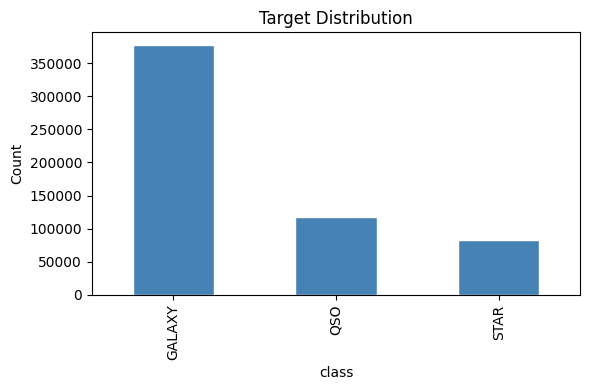

class
GALAXY    0.654
QSO       0.203
STAR      0.143
Name: ratio, dtype: float64


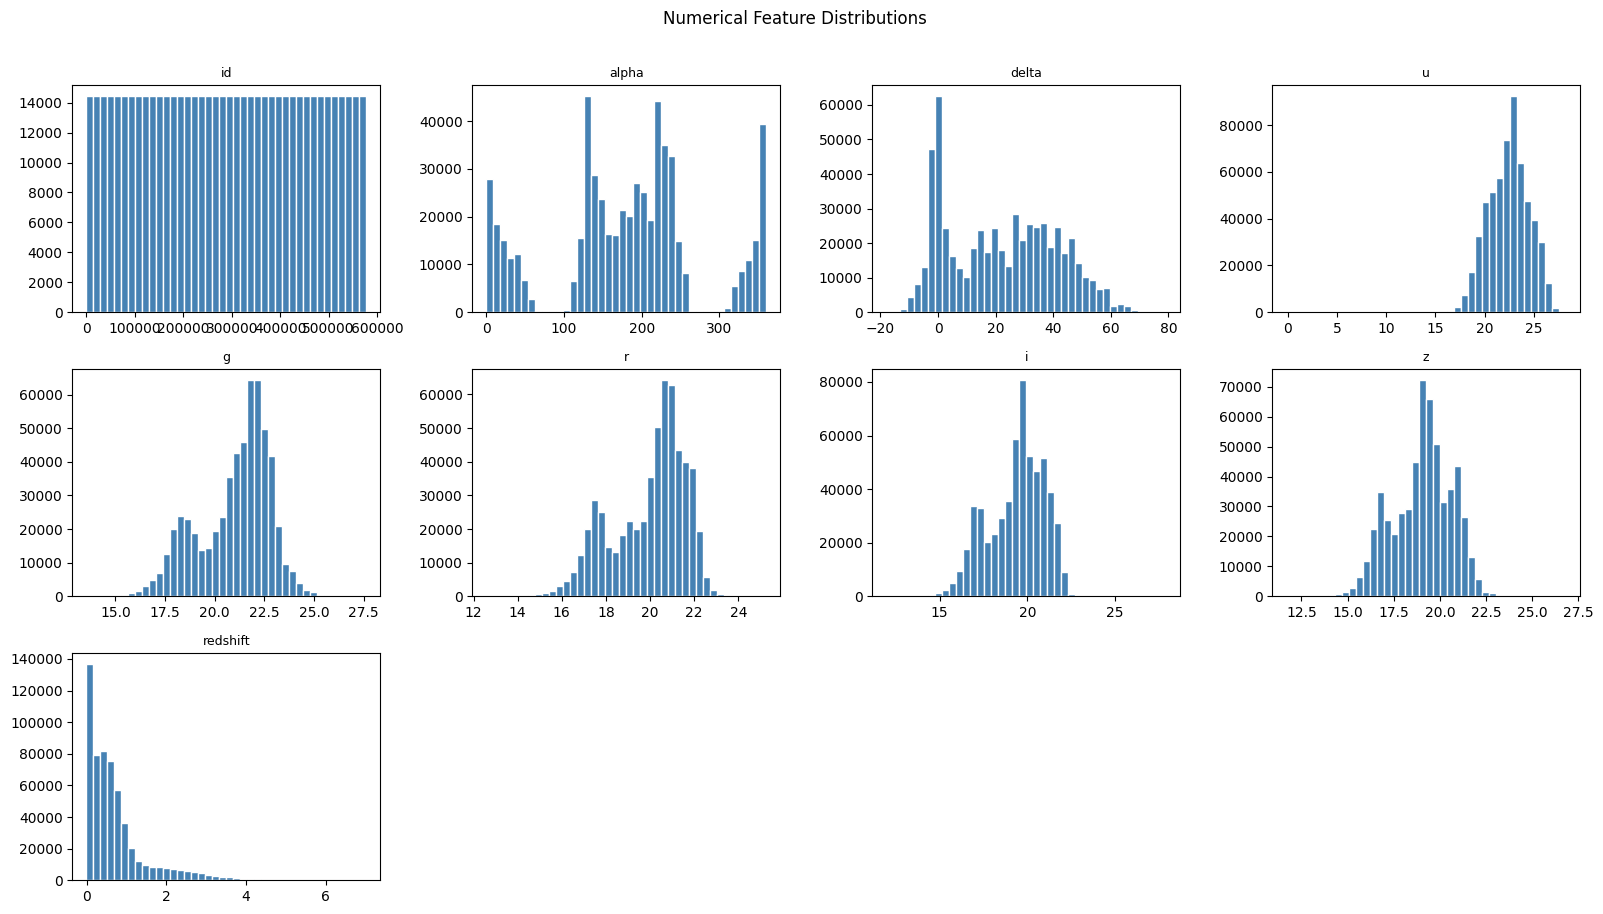

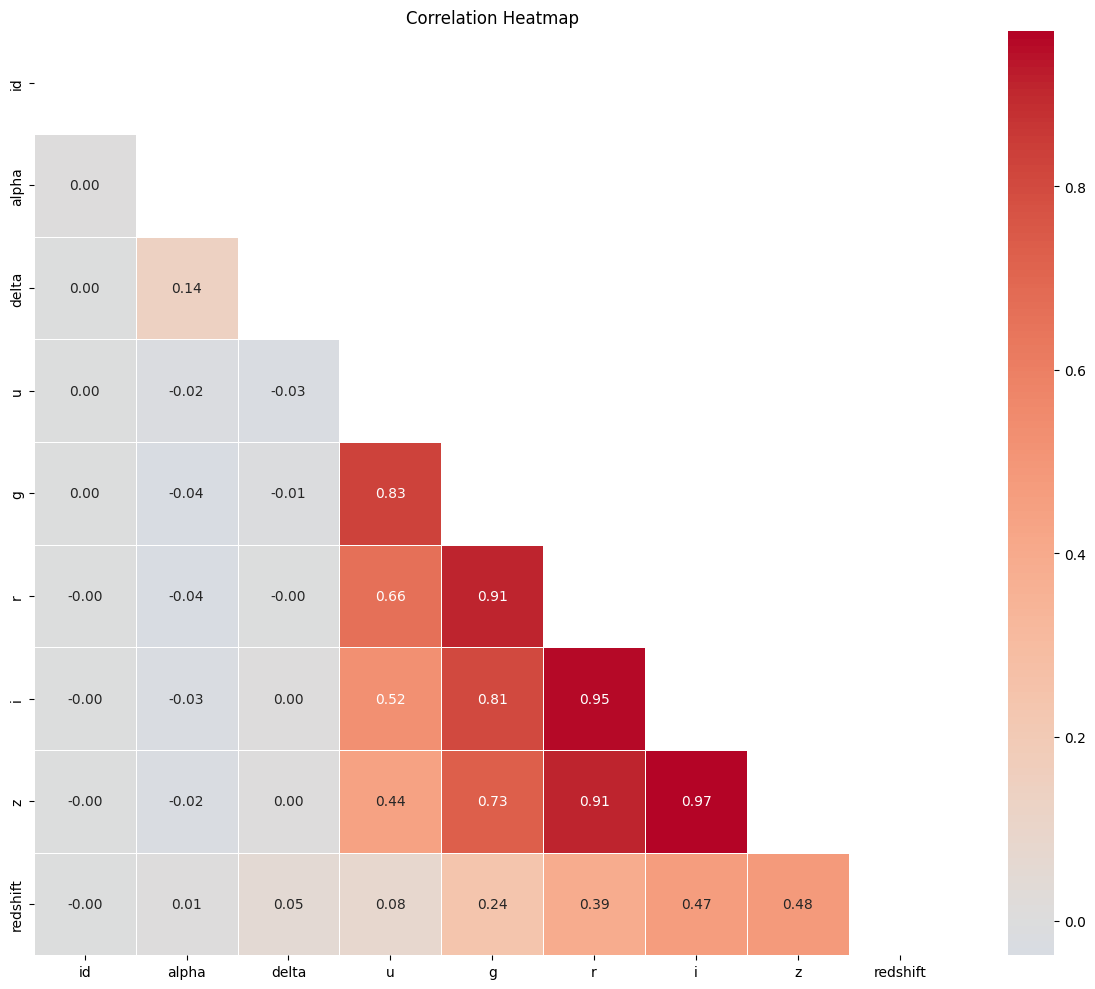


[spectral_type]  unique=4  null=0
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

[galaxy_population]  unique=2  null=0
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

[class]  unique=3  null=0
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


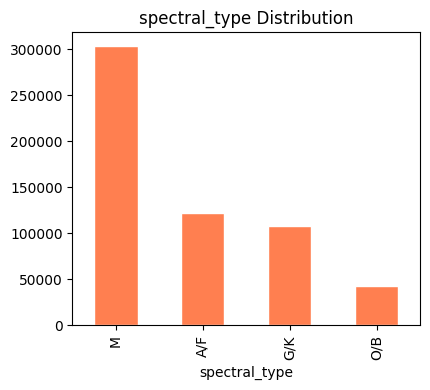

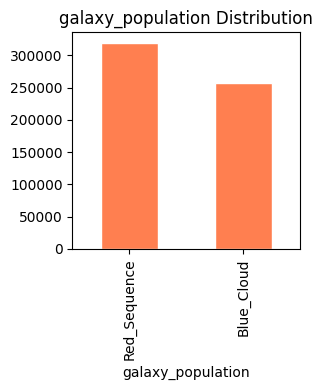

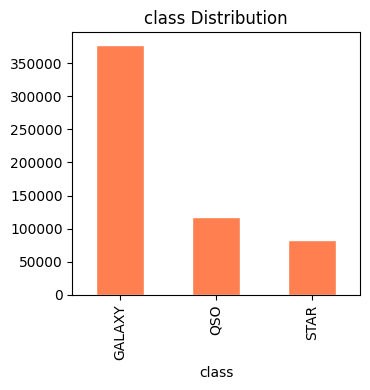

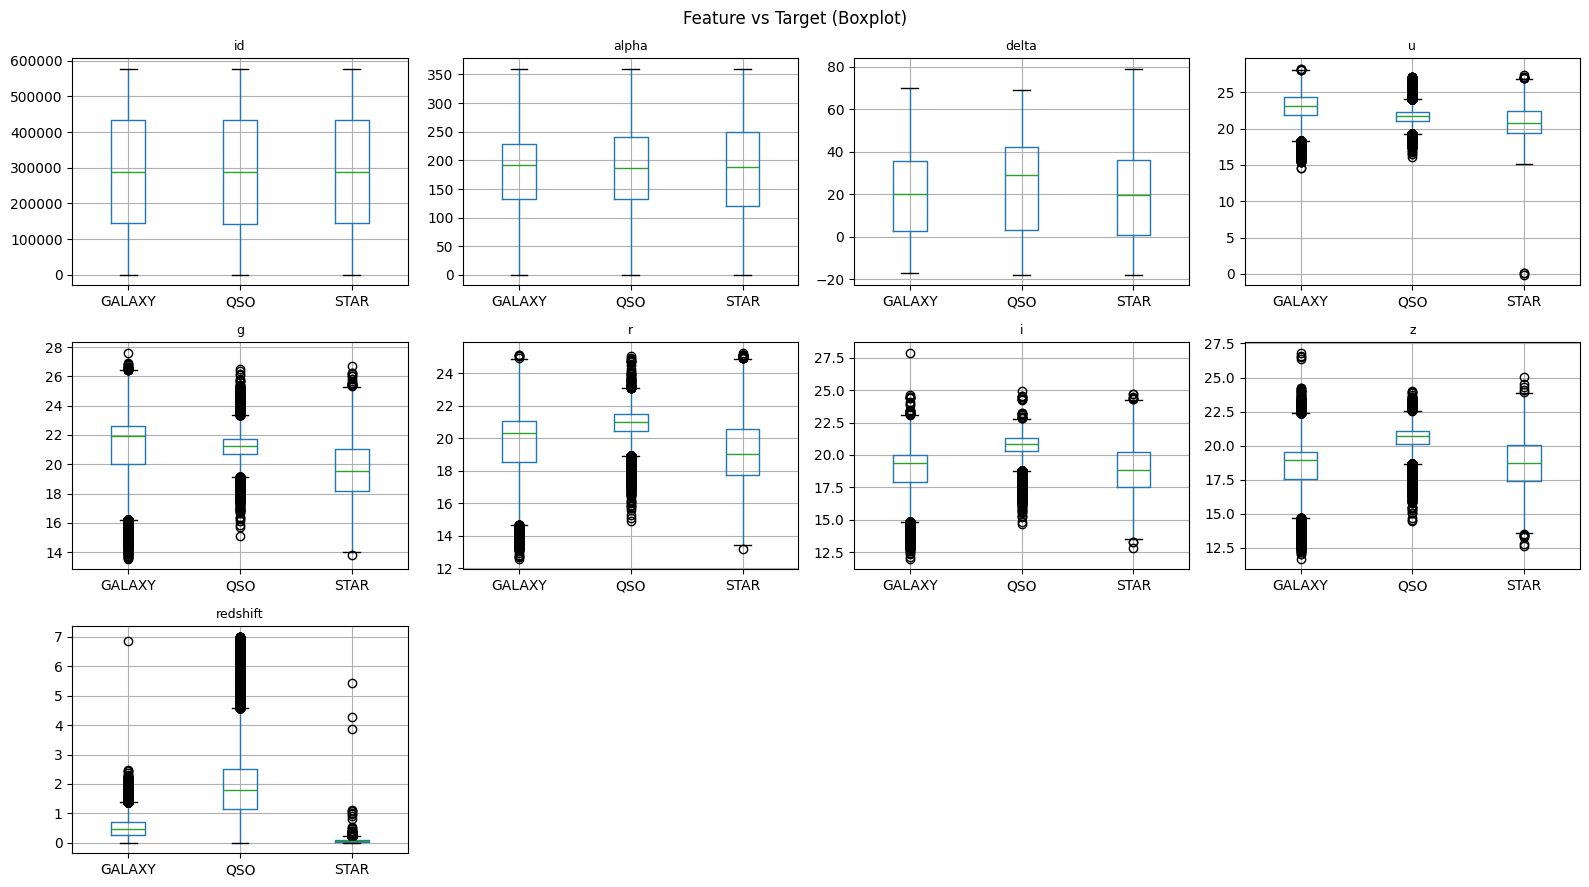

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===== データ読み込み =====
train = pd.read_csv("/home/kazok/kaggle/playground-s6e6/data/train.csv")
test  = pd.read_csv("/home/kazok/kaggle/playground-s6e6/data/test.csv")

target_col = "class"  # ← 目的変数のカラム名に変更してね

# ===== 基本情報 =====
print("=== Shape ===")
print(f"train: {train.shape}, test: {test.shape}")

print("\n=== dtypes & null ===")
print(train.dtypes.to_frame("dtype").join(
    train.isnull().sum().to_frame("null_count")
).assign(null_pct=lambda d: (d["null_count"] / len(train) * 100).round(2)))

# ===== 数値 / カテゴリ に分ける =====
num_cols = train.select_dtypes(include="number").columns.drop(target_col, errors="ignore").tolist()
cat_cols = train.select_dtypes(exclude="number").columns.tolist()

print(f"\n数値列: {len(num_cols)}本  カテゴリ列: {len(cat_cols)}本")

# ===== 数値特徴量: 基本統計量 =====
print("\n=== 数値特徴量 記述統計 ===")
desc = train[num_cols].describe().T
desc["skew"]     = train[num_cols].skew()
desc["kurtosis"] = train[num_cols].kurt()
print(desc.round(3))

# ===== 目的変数の分布 =====
plt.figure(figsize=(6, 4))
train[target_col].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Target Distribution")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(train[target_col].value_counts(normalize=True).rename("ratio").round(3))

# ===== 数値特徴量: 分布 (ヒストグラム) =====
n = len(num_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Numerical Feature Distributions", y=1.01)
plt.tight_layout()
plt.savefig("num_hist.png", dpi=150, bbox_inches="tight")
plt.show()

# ===== 数値特徴量: 相関ヒートマップ =====
plt.figure(figsize=(12, 10))
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=len(num_cols) <= 20, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("num_corr.png", dpi=150, bbox_inches="tight")
plt.show()

# ===== カテゴリ特徴量: 分布 =====
for col in cat_cols:
    vc = train[col].value_counts()
    print(f"\n[{col}]  unique={train[col].nunique()}  null={train[col].isnull().sum()}")
    print(vc.head(10))
    plt.figure(figsize=(min(len(vc) * 0.6 + 2, 12), 4))
    vc.head(20).plot(kind="bar", color="coral", edgecolor="white")
    plt.title(f"{col} Distribution")
    plt.tight_layout()
plt.savefig("cate_hist.png", dpi=150, bbox_inches="tight")


# ===== 目的変数 × 数値特徴量 (boxplot) =====
n = len(num_cols)
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    train.boxplot(column=col, by=target_col, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Feature vs Target (Boxplot)")
plt.tight_layout()
plt.savefig("Feature vs Target (Boxplot).png", dpi=150, bbox_inches="tight")

In [10]:

test["u_g"] = test["u"] - test["g"]
test["u_r"] = test["u"] - test["r"]
test["u_i"] = test["u"] - test["i"]
test["g_r"] = test["g"] - test["r"]
test["r_i"] = test["r"] - test["i"]
test["i_z"] = test["i"] - test["z"]

test["alpha_sin"] = np.sin(np.deg2rad(test["alpha"]))
test["alpha_cos"] = np.cos(np.deg2rad(test["alpha"]))

test["redshift_log"] = np.log1p(test["redshift"])

train["u_g"] = train["u"] - train["g"]
train["u_r"] = train["u"] - train["r"]
train["u_i"] = train["u"] - train["i"]
train["g_r"] = train["g"] - train["r"]
train["r_i"] = train["r"] - train["i"]
train["i_z"] = train["i"] - train["z"]

train["alpha_sin"] = np.sin(np.deg2rad(train["alpha"]))
train["alpha_cos"] = np.cos(np.deg2rad(train["alpha"]))

train["redshift_log"] = np.log1p(train["redshift"])



In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score  # ← 追加
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import KBinsDiscretizer

# ===== カテゴリ変数の準備 =====
cat_cols = ["spectral_type", "galaxy_population"]
for col in cat_cols:
    train[col] = train[col].astype("category")
    test[col]  = test[col].astype("category")

for col in ["alpha", "delta", "redshift", "u", "g", "r", "i", "z"]:
    cat_name = f"{col}_cat"
    train[cat_name] = np.floor(train[col]).astype("category")
    test[cat_name]  = np.floor(test[col]).astype("category")
    cat_cols.append(cat_name)

for df in [train, test]:
    df["alpha_delta_combo"] = (np.floor(df["alpha"]).astype(str) + "_" + np.floor(df["delta"]).astype(str)).astype("category")
    df["u_z_combo"] = (
        np.floor(df["u"]).astype(str) + "_" + np.floor(df["z"]).astype(str)
    ).astype("category")

cat_cols += ["alpha_delta_combo", "u_z_combo"]




# ===== 目的変数のエンコード =====
le = LabelEncoder()
train["class_encoded"] = le.fit_transform(train["class"])
# le.classes_ で対応確認できる → ['GALAXY' 'QSO' 'STAR']

# ===== 特徴量定義 =====
feature_cols = [
    "alpha", "delta", "u", "g", "r", "i", "z", "redshift",
    "u_g", "g_r", "r_i", "i_z",
    "alpha_sin", "alpha_cos", "redshift_log",
    "spectral_type", "galaxy_population",
    "alpha_cat", "delta_cat", "redshift_cat",
    "u_cat", "g_cat", "r_cat", "i_cat", "z_cat",
    # combo
    "alpha_delta_combo", "u_z_combo",
]

X = train[feature_cols]
y = train["class_encoded"]
X_test = test[feature_cols]

# ===== パラメータ =====
params = {
    "objective":      "multiclass",
    "num_class":      3,
    "metric":         "multi_logloss",
    "learning_rate":  0.05,
    "num_leaves":     63,
    "verbose":        -1,
    "is_unbalance":   True,   # クラス不均衡対策
}

# ===== Cross Validation =====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((len(train), 3))
test_preds = np.zeros((len(test), 3))

X_tst_base = X_test.copy()

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"--- Fold {fold+1} ---")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    X_tst = X_tst_base.copy()   # 毎foldリセット

    te_cols = ["alpha_delta_combo", "u_z_combo"]
    encoder = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
    tr_enc = encoder.fit_transform(X_tr[te_cols], y_tr)
    val_enc = encoder.transform(X_val[te_cols])

    te_names = [f"{col}_TE_cls{c}" for col in te_cols for c in range(3)]
    X_tr[te_names] = tr_enc
    X_val[te_names] = val_enc
    tst_enc = encoder.transform(X_tst[te_cols])
    X_tst[te_names] = tst_enc

    model = lgb.train(
        params,
        lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols),
        num_boost_round=1000,
        valid_sets=[lgb.Dataset(X_val, label=y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds         += model.predict(X_tst) / 5


# ===== OOF スコア確認 =====
oof_class = np.argmax(oof_preds, axis=1)
print(f"\nOOF Balanced Accuracy: {balanced_accuracy_score(y, oof_class):.4f}")  # ← 修正

# ===== 提出ファイル作成 =====
pred_labels = le.inverse_transform(np.argmax(test_preds, axis=1))
submission = pd.DataFrame({
    "id":    test["id"],
    "class": pred_labels
})
submission.to_csv("submission.csv", index=False)
print(submission["class"].value_counts())

--- Fold 1 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0940069
Early stopping, best iteration is:
[134]	valid_0's multi_logloss: 0.0925016
--- Fold 2 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0934833
Early stopping, best iteration is:
[144]	valid_0's multi_logloss: 0.0917975
--- Fold 3 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0955875
[200]	valid_0's multi_logloss: 0.0950649
Early stopping, best iteration is:
[150]	valid_0's multi_logloss: 0.0939916
--- Fold 4 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0961464
Early stopping, best iteration is:
[140]	valid_0's multi_logloss: 0.0946724
--- Fold 5 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.095037
Early stopping, best iteration is:
[142]	valid_0's multi_logloss: 0.093